# VLAB_04 — Block Signal Recharge and Routing Mode Control

Demonstrates the two new features added in the block-signal update:

1. **Block signal recharge** — a simple rectangular pulse as an alternative to the epikarst model.
2. **Routing mode** — control whether recharge enters the matrix only, the conduit only, or both.
3. **`crch_fraction`** — tune the matrix/conduit split at inlet cells in `routing_mode='both'`.

The workflow reuses a single network across all runs so that differences in the discharge response
can be attributed to the recharge routing rather than to different network geometries.

In [ ]:
# import sys
# sys.path.insert(0, "../..")

import vlab
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

## Configuration

In [2]:
NROW           = 20      # grid rows
NCOL           = 40      # grid columns
NSTP           = 24 * 6  # number of time steps per stress period
N_INLET        = 3       # number of sinkhole inlets
INLET_SEED     = 345      # spatial placement of inlets
SKS_SEED       = 123     # karst network skeleton seed

N_SP           = 10      # total simulation length (stress periods / days)
BLOCK_INTENS   = 50.    # recharge pulse intensity (mm/d)
SS_RCH         = 1.      # steady-state recharge (mm/d)
BLOCK_LEN      = 1       # pulse duration (days); followed by N_SP - BLOCK_LEN days of zero

CRCH_FRACS     = [0.1, 0.5, 0.9]   # crch_fraction values for the sweep

## Helper

In [3]:
def make_system(routing_mode="both", crch_fraction=1.0):
    """Build a fully-fixed System (no LHS sampling) with the given routing settings."""
    return vlab.System(
        n_rows=NROW,
        n_cols=NCOL,
        n_stress_periods=N_SP,
        recharge_source="block",
        ss_rch=SS_RCH,
        block_intensity=BLOCK_INTENS,
        block_length=BLOCK_LEN,
        routing_mode=routing_mode,
        groundwater=vlab.Groundwater(nstp=NSTP),
        network_structure=vlab.NetworkStructure(
            stochastic=False,
            n_inlets=N_INLET,
            values={"sks_seed": SKS_SEED},
            inlets_seed=INLET_SEED,
        ),
        recharge_params=vlab.RechargeParams(stochastic=False),
        network_properties=vlab.NetworkProperties(
            stochastic=False,
            values={"crch_fraction": crch_fraction,
                    "k_exchange": 1e-4,},
        ),
        aquifer_params=vlab.AquiferParams(
            stochastic=False,
            values={"hk": 1e-4,
                    "ss": 1e-4,
                    "sy": 1e-2}),
    )

## Step 1 — Block signal recharge

Show the recharge time series produced by `recharge_source='block'`:
a flat pulse of `BLOCK_INTENS` mm/d for `BLOCK_LEN` steps, then zero for the remaining stress periods.

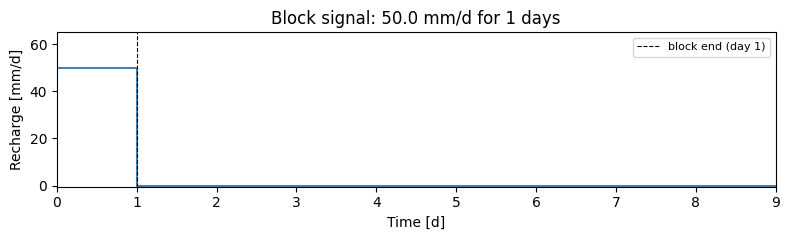

In [4]:
s_base = make_system()
rch = s_base.simulate_recharge()

fig, ax = plt.subplots(figsize=(8, 2.5))

ax.step(np.arange(N_SP), rch, where="post", c="steelblue", lw=1.5)
ax.axvline(BLOCK_LEN, ls="--", c="k", lw=0.8, label=f"block end (day {BLOCK_LEN})")
ax.set_xlim(0, N_SP - 1)
ax.set_ylim(-0.5, BLOCK_INTENS * 1.3)
ax.set_xlabel("Time [d]")
ax.set_ylabel("Recharge [mm/d]")
ax.legend(fontsize=8)
plt.title(f"Block signal: {BLOCK_INTENS} mm/d for {BLOCK_LEN} days")
plt.tight_layout()
plt.show()

## Step 2 — Generate network

Generate one karst network that will be reused for all routing-mode and crch_fraction experiments.
This isolates the effect of the routing settings from any network-geometry differences.

In [5]:
network = s_base.generate_network(random_state=None, cleanup=True)


Always visually check the validated network for structuralcorrectness! 
i.e., whether branches are correctly isolated or ifthey got connected during processing.


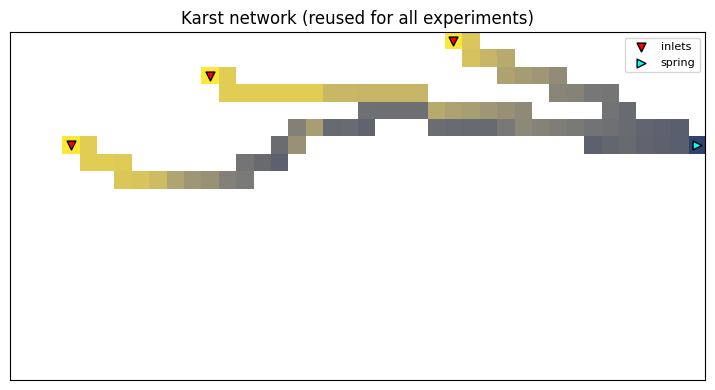

In [6]:
# Always visually check the network for structural correctness
fig, ax = plt.subplots(figsize=(NCOL / 5, NROW / 5))

nplot = network.validator.network.copy().astype(float)
nplot[nplot == 0] = np.nan
ax.matshow(nplot, cmap="cividis", vmin=2, vmax=11)

inlets = np.array(network.idxs_inlet)
ax.scatter(
    inlets[:, 0] - 1, inlets[:, 1] - 1,
    c="r", marker="v", edgecolors="k", s=40, zorder=5, label="inlets",
)
ax.scatter(
    [network.idxs_spring[0] - 1], [network.idxs_spring[1] - 1],
    c="cyan", marker=">", edgecolors="k", s=40, zorder=5, label="spring",
)

ax.set_xticks([])
ax.set_yticks([])
ax.legend(fontsize=8, loc="upper right")
plt.title("Karst network (reused for all experiments)")
plt.tight_layout()
plt.show()

## Step 3 — Routing mode comparison

Run the same block signal through the same network with each of the three routing modes:

| Mode | Matrix RCH | Conduit CRCH |
|---|---|---|
| `both` | uniform over all cells | `crch_fraction` at inlet nodes |
| `matrix_only` | uniform over all cells | 0 everywhere |
| `conduit_only` | 0 except at inlet cells | 1.0 at inlet nodes |

For `both` mode here, `crch_fraction=1.0` (maximum conduit input) so the contrast to `conduit_only` reflects the spatial concentration of recharge rather than its magnitude.

In [7]:
routing_modes  = ["both", "matrix_only", "conduit_only"]
mode_colors    = {"both": "steelblue", "matrix_only": "saddlebrown", "conduit_only": "darkorange"}

discharge_mode = {}   # mode → Q_out pd.Series

for mode in routing_modes:
    s = make_system(routing_mode=mode, crch_fraction=1.0)
    success, Q_out, _ = s.simulate_from_network(
        network=network, random_state=None, cleanup=True
    )
    discharge_mode[mode] = Q_out
    print(f"  {mode:<15}  success={success}")

Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.02 s
  both             success=True
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.02 s
  matrix_only      success=True
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.01 s
  conduit_only     success=True


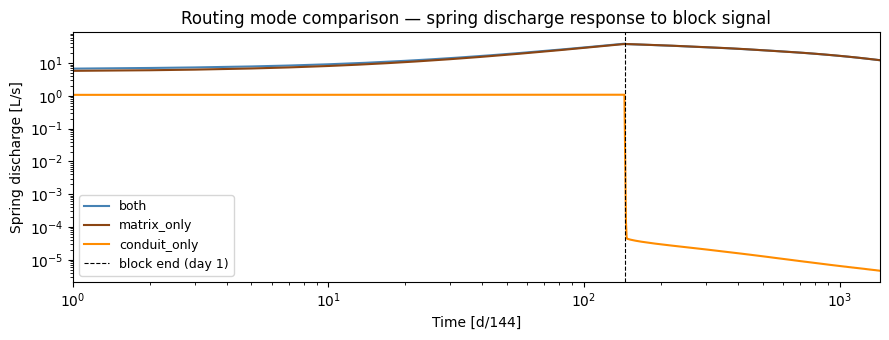

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.5))

for mode, Q in discharge_mode.items():
    ax.plot(Q.values * 1000, label=mode, c=mode_colors[mode], lw=1.5)   # m³/s → L/s

ax.axvline((BLOCK_LEN * NSTP) + 1, ls="--", c="k", lw=0.8, label=f"block end (day {BLOCK_LEN})")
ax.set_yscale("log")
ax.set_xlim(1, N_SP * NSTP)
ax.set_xlabel(f"Time [d/{NSTP}]")
ax.set_ylabel("Spring discharge [L/s]")
ax.set_xscale("log")

ax.legend(fontsize=9)
plt.title("Routing mode comparison — spring discharge response to block signal")
plt.tight_layout()
plt.show()

## Step 4 — `crch_fraction` sensitivity

`crch_fraction` controls what fraction of the recharge at each inlet cell is routed into the conduit
(rather than staying in the matrix). Only active in `routing_mode='both'`.

A sweep from 0.0 (all matrix) to 1.0 (maximum conduit input) shows how the fraction
shifts the discharge response from a slow matrix-dominated signal to a faster conduit-dominated one.

In [9]:
discharge_frac = {}   # crch_fraction value → Q_out pd.Series

for frac in CRCH_FRACS:
    s = make_system(routing_mode="both", crch_fraction=frac)
    success, Q_out, _ = s.simulate_from_network(
        network=network, random_state=None, cleanup=True
    )
    discharge_frac[frac] = Q_out
    print(f"  crch_fraction={frac:.2f}  success={success}")

Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.01 s
  crch_fraction=0.10  success=True
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.02 s
  crch_fraction=0.50  success=True
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.01 s
  crch_fraction=0.90  success=True


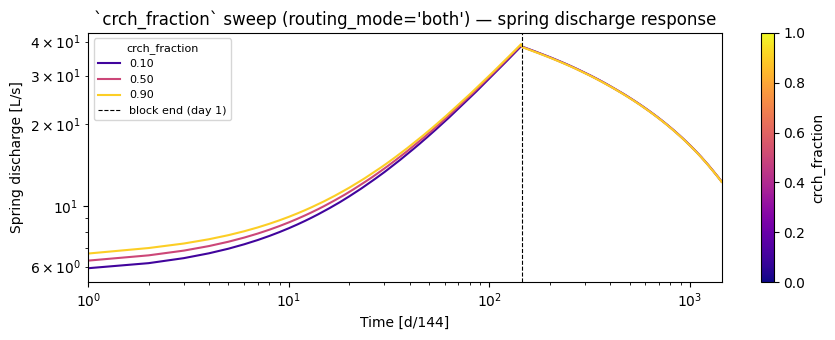

In [10]:
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=0, vmax=1)

fig, ax = plt.subplots(figsize=(9, 3.5))

for frac, Q in discharge_frac.items():
    ax.plot(Q.values * 1000, c=cmap(norm(frac)), lw=1.5, label=f"{frac:.2f}")

ax.axvline((BLOCK_LEN * NSTP) + 1, ls="--", c="k", lw=0.8, label=f"block end (day {BLOCK_LEN})")
ax.set_yscale("log")
ax.set_xlim(1, N_SP * NSTP)
ax.set_xlabel(f"Time [d/{NSTP}]")
ax.set_ylabel("Spring discharge [L/s]")
ax.set_xscale("log")
ax.legend(title="crch_fraction", fontsize=8, title_fontsize=8)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="crch_fraction")
plt.title("`crch_fraction` sweep (routing_mode='both') — spring discharge response")
plt.tight_layout()
plt.show()